<h1 align="center">Feature Scaling</h1>

Feature scaling is a technique used for optimizing Gradient Descent by rescaling the features. The need for freature rescaling arises when features for the same model have vastly different ranges. It is a part of the `feature engineering` process which works with selecting, modifying and or creating new features for better model accuracy.

<img src="../images/feature-engineering.webp" style="display: block; margin: 0 auto;" width="900">

#### It contributes to model building in the following ways:

* Well-designed features help the model to learn complex patterns more effectively.
* Removing noise and irrelevant information improves model prediction accuracy.
* Focusing on meaningful features helps the model to generalize better and reduces overfitting.
* Clear and informative features make the model easier to understand and interpret.

<h1 align="center">Types of feature scaling techniques</h1>

<img src="../images/feature_engineering_types.webp" style="display: block; margin: 0 auto;" width="900">


For Feature Scaling particularly there exist 3 main ways of implementation:
* Absolute Maximum Scaling
* Z score Normalization
* Mean(min-max) normalization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Housing.csv')

df.head()

,square_feet,bedrooms,price
0,1220,1,242320
1,2609,5,502451
2,2109,4,453468
3,2006,3,365326
4,1343,3,232943


From the above example after importing the data we can see that there is a huge range discrepancy between the data features.


In [2]:
print(f'Maximum values for: {df.max()}')
print(f'Minimum values for: {df.min()}')

Maximum values for: square_feet      3303
bedrooms            6
price          621579
dtype: int64
Minimum values for: square_feet      450
bedrooms           1
price          89108
dtype: int64


## Gradient Descent without feature scaling

For the first example we will split the data and use linear regression and look at the contour plot for gradient descent without feature scaling

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = (df.drop(columns='price')).to_numpy()
y = (df['price']).to_numpy()

# X = features dataframe/array, y = target labels array
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20,      # Allocates 20% of data to the test set
    random_state=42,     # Seeds the generator for reproducible results
    shuffle=True         # Shuffles data before splitting
)

print(X.shape[0])
print(y.shape[0])

250
250


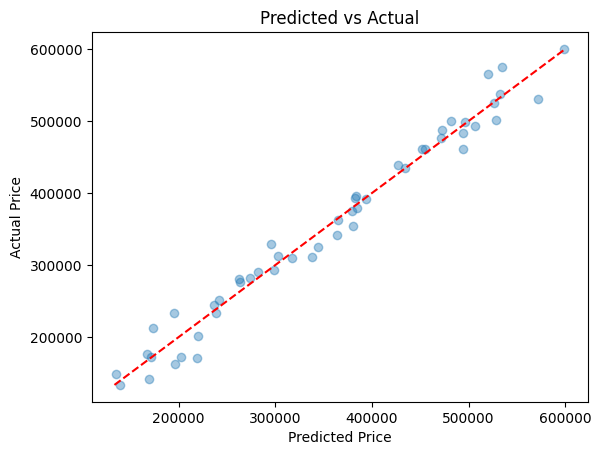

In [4]:
# Create a linear regression model
model = LinearRegression()
# Fit the model to the training data
model.fit(X_train, y_train)
# Make predictions using the trained model
y_pred = model.predict(X_test)


plt.scatter(y_pred, y_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect line
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("Predicted vs Actual")
plt.show()

In [5]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print(f"Cost function: {mse}")

Cost function: 438968638.21309227


In [6]:
"""
    Cost Function to showcase the error size while getting the best values for w and b
"""


def cost_function(X, y, w, b):
    m = X.shape[0]
    f_wb = X @ w + b              # (200,2) @ (2,) -> (200,)  one prediction per house
    cost = np.sum((f_wb - y) ** 2) / (2 * m)
    return cost

w = np.array([140.0, 18000.0])   # weight for sqft, weight for bedrooms
b = 35000.0

print(cost_function(X_train, y_train, w, b))


254564037.965


In [7]:
"""
    In this section the error that were getting is normal, 
    this happens beacuse of the discrepancy of scale between the two features,
    square feet has huge range values:
    
    --MAX--
    Maximum values for: square_feet      3303
    bedrooms            6
    
    --MIN--
    Minimum values for: square_feet      450
    bedrooms           1
    
    What happens is the contour plot of gradient descent looks more longated circle,
    where the long part is the bedroom amount and the shorter square feet.
    
    And beacuse of this what happens for a single change in square_feet we get a larger change, and for bedrooms feautre we get a smaller change.
    And beacuse Alpha is serving both the same what we get is a large alpha taking steps too large in one direction(square_feet),
    and too small in the other(bedroom amount).
    
    Thus for large values of alpha we never get a convergence and we go into infinity,
    where as for small alpha values it will take forever to reach convergence
    
    This problem is the exact thing feature scaling tries to solve
    
    In the markdown below there is also an explanation of this
"""


def compute_gradient(X, y, w, b):
    m = X.shape[0]
    f_wb = X @ w + b                 # (m,)  predictions, one per house
    errors = f_wb - y                # (m,)
    dj_dw = (1/m) * (X.T @ errors)   # (n,)  one slope per feature 
    dj_db = (1/m) * np.sum(errors)   # scalar 
    return dj_dw, dj_db

def gradient_descent(X, y, w, b, alpha, iterations):
    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i % 100 == 0:
            cost = cost_function(X, y, w, b)
            print(f"Iter {i:4d}: cost={cost:.3e}  w={np.round(w,2)}  b={b:.2f}")
    return w, b

w_init = np.zeros(X_train.shape[1])
b_init = 0.0       
alpha = 0.01                   
iterations = 1000

w_final, b_final = gradient_descent(X_train, y_train, w_init, b_init, alpha, iterations)
try:
    print(f"\nFinal: w = {w_final:.2f}, b = {b_final:.2f}")
except TypeError:
    print(f"\nFinal: w = {np.round(w_final, 2)}, b = {b_final:.2f}")


Iter    0: cost=1.026e+20  w=[7324393.26   14329.15]  b=3543.56
Iter  100: cost=nan  w=[nan nan]  b=nan
Iter  200: cost=nan  w=[nan nan]  b=nan
Iter  300: cost=nan  w=[nan nan]  b=nan
Iter  400: cost=nan  w=[nan nan]  b=nan
Iter  500: cost=nan  w=[nan nan]  b=nan
Iter  600: cost=nan  w=[nan nan]  b=nan
Iter  700: cost=nan  w=[nan nan]  b=nan
Iter  800: cost=nan  w=[nan nan]  b=nan
Iter  900: cost=nan  w=[nan nan]  b=nan

Final: w = [nan nan], b = nan


/var/folders/j6/09f5n__n4f5fhrjb290ynm140000gn/T/ipykernel_17444/2339481256.py:41: RuntimeWarning: invalid value encountered in subtract
  w = w - alpha * dj_dw


## What feature scaling fixes

Imagine the cost function as a **landscape** and gradient descent as a blindfolded hiker
trying to walk to the lowest point. At every step the hiker feels the slope under their
boots and takes a stride downhill of size $\alpha$ (the learning rate). The position of the
hiker is the set of weights $(w_1, w_2, b)$.

The catch: our two features live on completely different scales.

| feature | min | max |
|---|---|---|
| `square_feet` | 450 | 3303 |
| `bedrooms` | 1 | 6 |

`square_feet` ranges over **thousands**, `bedrooms` over a **handful**. That single fact is
what blows everything up.

### The system in 3 equations

**Prediction** — each house gets one price:
$$f_{\mathbf{w},b}(\mathbf{x}) = w_1 x_1 + w_2 x_2 + b$$

**Cost** — average squared miss across all $m$ houses:
$$J(\mathbf{w}, b) = \frac{1}{2m}\sum_{i=1}^{m}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)^2$$

**Gradient** — the slope the hiker feels in the $w_j$ direction:
$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}\left(f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}\right)\, x_j^{(i)}$$

**Update** — take a step downhill:
$$w_j := w_j - \alpha\,\frac{\partial J}{\partial w_j}$$

### The lopsided slope

Look hard at the gradient: every term is multiplied by $x_j^{(i)}$ — the feature's own value.
So the size of the slope for a weight is **tied to the size of that feature**.

- $x_1$ (`square_feet`) is in the thousands → its gradient term is huge.
- $x_2$ (`bedrooms`) is in single digits → its gradient term is tiny.

Same error, same formula, but the sqft slope comes out roughly a **thousand times steeper**
than the bedrooms slope. (We saw this live: in one step $w_1$ flew to ~7.3 million while
$w_2$ barely reached ~14 thousand.)

### The canyon

Because of that imbalance, the landscape isn't a nice round bowl — it's a long, narrow
**canyon**. The contour plot is a stretched-out ellipse: the **steep, narrow wall** is the
`square_feet` direction, the **gentle, wide floor** is the `bedrooms` direction.

A tiny change in $w_1$ swings the cost violently. A change in $w_2$ barely moves it.

### Why one $\alpha$ can't win

There's only **one** learning rate $\alpha$, and it has to serve both directions at once.
That's the trap:

- Pick $\alpha$ **large enough** to make progress along the gentle bedrooms floor →
  it's far too large for the steep sqft wall. The hiker overshoots, lands higher up the
  opposite wall, overshoots harder next time, and the cost rockets to $\infty$ then `NaN`.
- Pick $\alpha$ **small enough** to be safe on the steep sqft wall →
  it's so tiny that movement along the bedrooms floor takes *forever* to converge.

You're stuck between **diverging** and **crawling**. There's no good $\alpha$ for a canyon.

### The fix: feature scaling

Reshape the canyon back into a **round bowl**, so one $\alpha$ works in every direction.
Bring both features onto the same scale. Standardization (z-score):

$$x_j' = \frac{x_j - \mu_j}{\sigma_j}$$

where $\mu_j$ is the feature's mean and $\sigma_j$ its standard deviation. Now both features
have mean $0$ and std $1$, their gradients become comparable, the elongated ellipse becomes
near-circular, and gradient descent walks straight to the bottom.

(Alternative — min-max scaling, squashes into $[0, 1]$:)
$$x_j' = \frac{x_j - \min(x_j)}{\max(x_j) - \min(x_j)}$$

### Takeaway

Gradient descent doesn't actually fail on hard problems — it fails on **badly shaped**
ones. Feature scaling doesn't change *where* the minimum is, only the *shape of the road*
to get there: canyon → bowl, so a single $\alpha$ can finally serve every direction at once.

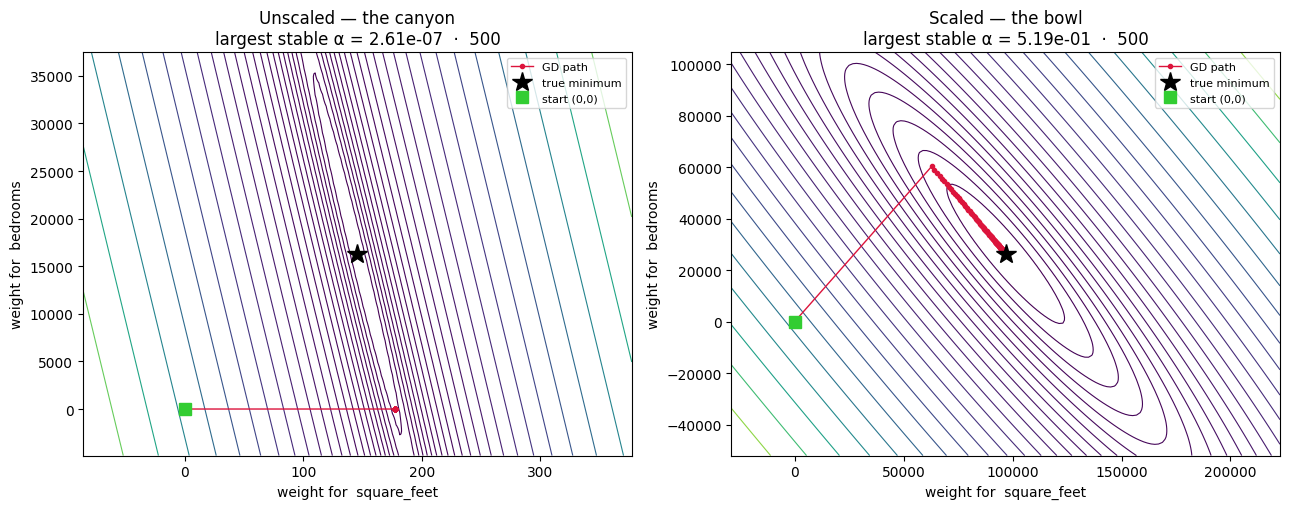

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Reuses the data already in memory
X = np.asarray(X_train, dtype=float)
y = np.asarray(y_train, dtype=float)
m = X.shape[0]

def cost(Xm, w, b):
    err = Xm @ w + b - y
    return (err @ err) / (2 * m)

def stable_alpha(Xm):
    # Hessian of J w.r.t. w is (1/m) XᵀX. GD is stable only while alpha < 2/lam_max.
    H = (Xm.T @ Xm) / m
    return 1.0 / np.linalg.eigvalsh(H).max()   # the LARGEST alpha that won't explode

def run_gd(Xm, alpha, steps, w0):
    # Freeze b at its best value so the two weights live on a flat 2D map we can draw.
    Xb = np.c_[Xm, np.ones(m)]
    theta = np.linalg.solve(Xb.T @ Xb, Xb.T @ y)
    w_star, b = theta[:2], theta[2]
    w = w0.copy(); path = [w.copy()]
    for _ in range(steps):
        w = w - alpha * (Xm.T @ (Xm @ w + b - y)) / m
        path.append(w.copy())
    return np.array(path), w_star, b

mu, sigma = X.mean(0), X.std(0)
Xs = (X - mu) / sigma                          # scaled twin of the features

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for ax, Xm, title in [(axes[0], X,  "Unscaled — the canyon"),
                      (axes[1], Xs, "Scaled — the bowl")]:
    alpha = stable_alpha(Xm)
    steps = 500
    path, w_star, b = run_gd(Xm, alpha, steps, np.array([0.0, 0.0]))

    # grid wide enough to hold both the start and the true minimum
    span1 = max(np.abs(path[:, 0]).max(), abs(w_star[0])) * 1.3 + 1
    span2 = max(np.abs(path[:, 1]).max(), abs(w_star[1])) * 1.3 + 1
    w1 = np.linspace(w_star[0] - span1, w_star[0] + span1, 150)
    w2 = np.linspace(w_star[1] - span2, w_star[1] + span2, 150)
    W1, W2 = np.meshgrid(w1, w2)
    Z = np.array([[cost(Xm, np.array([a, c]), b) for a in w1] for c in w2])

    levels = np.logspace(np.log10(Z.min() + 1), np.log10(Z.max()), 25)
    ax.contour(W1, W2, Z, levels=levels, cmap="viridis", linewidths=0.8)
    ax.plot(path[:, 0], path[:, 1], "o-", color="crimson", ms=3, lw=1, label="GD path")
    ax.plot(*w_star, "k*", ms=15, label="true minimum")
    ax.plot(path[0, 0], path[0, 1], "s", color="limegreen", ms=9, label="start (0,0)")
    ax.set_xlabel("weight for  square_feet")
    ax.set_ylabel("weight for  bedrooms")
    ax.set_title(f"{title}\nlargest stable α = {alpha:.2e}  ·  {steps}")
    ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from ipywidgets import interact, FloatLogSlider, IntSlider, Dropdown, FloatText

X = np.asarray(X_train, dtype=float)
y = np.asarray(y_train, dtype=float)
m = X.shape[0]

def draw(scaling="standardize", alpha=0.1, iterations=80,
         w1_start=0.0, w2_start=0.0, elev=35, azim=-60):

    if scaling == "standardize":
        Xm = (X - X.mean(0)) / X.std(0)
    elif scaling == "min-max":
        Xm = (X - X.min(0)) / (X.max(0) - X.min(0))
    else:
        Xm = X.copy()

    # true minimum (b frozen at its best value so we can draw a 2-weight map)
    Xb = np.c_[Xm, np.ones(m)]
    theta = np.linalg.solve(Xb.T @ Xb, Xb.T @ y)
    w_star, b = theta[:2], theta[2]

    # run your gradient descent with the chosen dials
    w = np.array([w1_start, w2_start], dtype=float)
    path = [w.copy()]
    with np.errstate(over="ignore", invalid="ignore"):
        for _ in range(int(iterations)):
            w = w - alpha * (Xm.T @ (Xm @ w + b - y)) / m
            path.append(w.copy())
    path = np.array(path)

    # cost surface around the optimum (vectorised so dragging stays snappy)
    span1 = (abs(w_star[0]) + abs(w1_start) + 1) * 1.25
    span2 = (abs(w_star[1]) + abs(w2_start) + 1) * 1.25
    w1 = np.linspace(w_star[0] - span1, w_star[0] + span1, 80)
    w2 = np.linspace(w_star[1] - span2, w_star[1] + span2, 80)
    W1, W2 = np.meshgrid(w1, w2)
    pred = W1[..., None] * Xm[:, 0] + W2[..., None] * Xm[:, 1] + b
    Z = ((pred - y) ** 2).sum(-1) / (2 * m)
    Zlog = np.log10(Z + 1)

    with np.errstate(over="ignore", invalid="ignore"):
        step_cost = (((Xm @ path.T).T + b - y) ** 2).sum(1) / (2 * m)
    path_z = np.log10(step_cost + 1)

    # keep only path points that are finite AND still on the map
    on = (np.isfinite(path).all(1) & np.isfinite(path_z)
          & (path[:, 0] >= w1.min()) & (path[:, 0] <= w1.max())
          & (path[:, 1] >= w2.min()) & (path[:, 1] <= w2.max()))

    diverged = not np.isfinite(step_cost[-1]) or step_cost[-1] > step_cost[0] * 10
    status = "DIVERGED ✗" if diverged else f"converged ✓  (cost {step_cost[-1]:.2e})"

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(W1, W2, Zlog, cmap="viridis", alpha=0.72,
                    linewidth=0, antialiased=True, rstride=2, cstride=2)
    ax.contour(W1, W2, Zlog, levels=15, zdir="z", offset=Zlog.min(),
               cmap="viridis", linewidths=0.6)
    if on.sum() > 0:
        ax.plot(path[on, 0], path[on, 1], path_z[on], "o-", color="crimson",
                ms=3, lw=1.6, zorder=10, label="GD path")
    ax.scatter(*w_star, np.log10(((Xm @ w_star + b - y) ** 2).sum() / (2 * m) + 1),
               color="black", marker="*", s=220, label="minimum")
    ax.scatter(path[0, 0], path[0, 1], path_z[0],
               color="limegreen", marker="s", s=70, label="start")
    ax.set_xlabel("w  square_feet"); ax.set_ylabel("w  bedrooms")
    ax.set_zlabel("log₁₀ cost J")
    ax.set_title(f"{scaling}  ·  α = {alpha:.1e}  ·  {int(iterations)} steps  ·  {status}")
    ax.view_init(elev=elev, azim=azim)
    ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()

interact(
    draw,
    scaling=Dropdown(options=["none", "standardize", "min-max"], value="standardize", description="scaling"),
    alpha=FloatLogSlider(base=10, min=-9, max=0.3, step=0.1, value=0.1, description="α"),
    iterations=IntSlider(min=1, max=500, step=1, value=80, description="steps"),
    w1_start=FloatText(value=0.0, description="start w₁"),
    w2_start=FloatText(value=0.0, description="start w₂"),
    elev=IntSlider(min=0, max=90, step=5, value=35, description="elev"),
    azim=IntSlider(min=-180, max=180, step=5, value=-60, description="azim"),
);

interactive(children=(Dropdown(description='scaling', index=1, options=('none', 'standardize', 'min-max'), val…